# Airbnb NYC - Data Cleaning & Visualization
AI & Data Science Assignment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('airbnb.csv')
print(df.shape)
df.head()

(1040, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    str    
 2   host_id                         1040 non-null   str    
 3   host_name                       913 non-null    str    
 4   neighbourhood_group             1040 non-null   str    
 5   neighbourhood                   1035 non-null   str    
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   str    
 8   room_type                       1040 non-null   str    
 9   price                           1040 non-null   str    
 10  minimum_nights                  1040 non-null   str    
 11  number_of_reviews               1040 non-null   str    
 12  last_review                     1027 non-null

In [3]:
df.isnull().sum()

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64

## Fixing text columns (casing, spelling)

In [4]:
df['room_type'] = df['room_type'].str.strip().str.lower()
df['room_type'] = df['room_type'].replace({'???': np.nan})
df['room_type'] = df['room_type'].str.title()
df['room_type'].value_counts(dropna=False)

room_type
Private Room       449
Entire Home/Apt    434
Shared Room        156
NaN                  1
Name: count, dtype: int64

In [5]:
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip().str.lower()
fix_map = {'manhatan': 'manhattan', 'the bronx': 'bronx'}
df['neighbourhood_group'] = df['neighbourhood_group'].replace(fix_map)
df['neighbourhood_group'] = df['neighbourhood_group'].str.title()
df['neighbourhood_group'].value_counts(dropna=False)

neighbourhood_group
Staten Island    230
Manhattan        229
Brooklyn         213
Bronx            195
Queens           173
Name: count, dtype: int64

## Fixing data types

In [6]:
def clean_numeric(series):
    cleaned = series.astype(str).str.replace('$', '', regex=False).str.strip()
    return pd.to_numeric(cleaned, errors='coerce')

numeric_cols = ['price', 'minimum_nights', 'number_of_reviews',
                 'reviews_per_month', 'calculated_host_listings_count', 'longitude']

for col in numeric_cols:
    df[col] = clean_numeric(df[col])

df[numeric_cols].dtypes

price                             float64
minimum_nights                    float64
number_of_reviews                 float64
reviews_per_month                 float64
calculated_host_listings_count    float64
longitude                         float64
dtype: object

In [7]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce', dayfirst=True)
df['last_review'].head()

0   2019-09-04
1   2014-10-14
2   2013-08-11
3          NaT
4   2012-03-01
Name: last_review, dtype: datetime64[us]

## Handling missing values

Strategy for each column:
- `name`, `host_name` -> filled with "Unknown" (text field, no average makes sense)
- `neighbourhood`, `room_type` -> filled with mode (categorical, most common value is the safest guess)
- `latitude`, `price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count` -> filled with median (these are skewed by extreme values, so median is more representative than mean)
- `reviews_per_month` -> filled with 0 (a missing value here almost always means the listing simply has no reviews yet, so 0 is the actual correct value, not just a filler)
- `last_review` -> left as NaT (missing date = never reviewed, there's no meaningful "average date" to substitute)

In [8]:
df.isnull().sum()

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           2
room_type                           1
price                              19
minimum_nights                      5
number_of_reviews                   2
last_review                       433
reviews_per_month                  55
calculated_host_listings_count      3
availability_365                    0
dtype: int64

In [9]:
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])
df['room_type'] = df['room_type'].fillna(df['room_type'].mode()[0])

for col in ['latitude', 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count']:
    df[col] = df[col].fillna(df[col].median())

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df.isnull().sum()

id                                  0
name                                0
host_id                             0
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           2
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       433
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

## Duplicates

In [10]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate ids:', df['id'].duplicated().sum())

df = df.drop_duplicates()
df = df.drop_duplicates(subset='id', keep='first')

print('Shape after dropping duplicates:', df.shape)

Duplicate rows: 31
Duplicate ids: 40
Shape after dropping duplicates: (1000, 16)


## Outliers (IQR method)

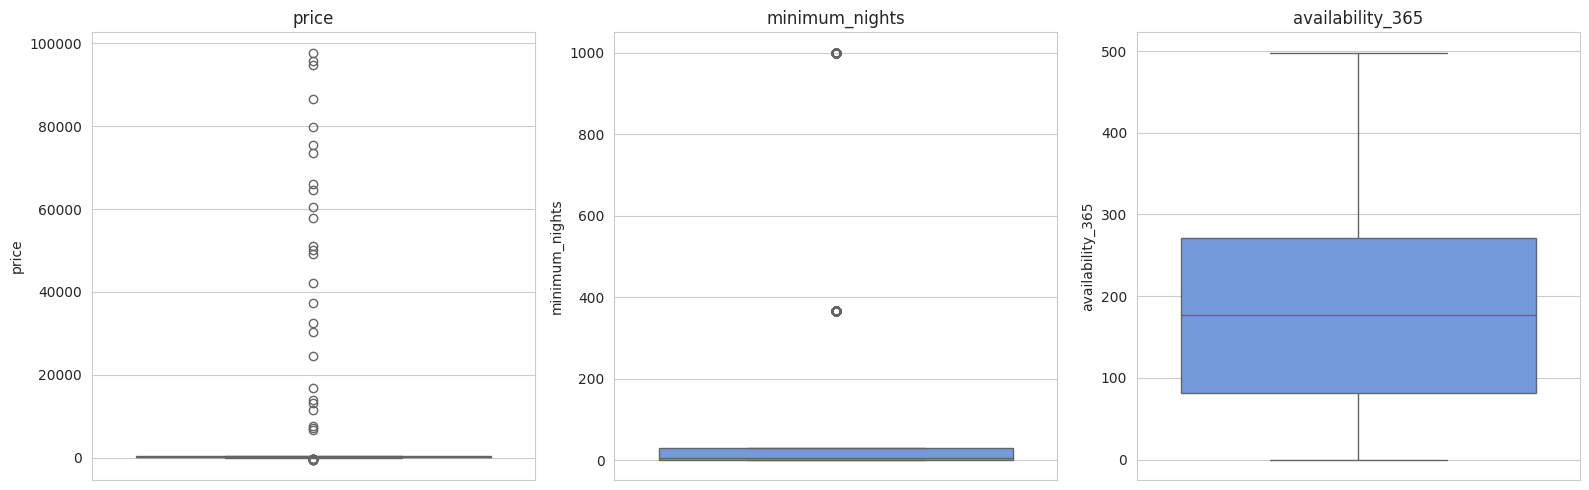

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['price', 'minimum_nights', 'availability_365']):
    sns.boxplot(y=df[col], ax=ax, color='cornflowerblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

for col in ['price', 'minimum_nights', 'availability_365']:
    lower, upper = iqr_bounds(df[col])
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: bounds = ({lower:.2f}, {upper:.2f}), outliers = {count}')

price: bounds = (-214.25, 735.75), outliers = 38
minimum_nights: bounds = (-42.50, 73.50), outliers = 195
availability_365: bounds = (-201.50, 554.50), outliers = 0


In [13]:
# capping instead of dropping, so we don't lose real listings
for col in ['price', 'minimum_nights', 'availability_365']:
    lower, upper = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=lower, upper=upper)

df[['price', 'minimum_nights', 'availability_365']].describe()

,price,minimum_nights,availability_365
count,1000.000000,1000.000000,1000.000000
mean,261.094500,19.402500,181.345000
std,164.172559,27.891857,109.961163
min,-214.250000,1.000000,0.000000
25%,142.000000,1.000000,82.000000
50%,257.000000,5.000000,177.000000
75%,379.500000,30.000000,271.000000
max,735.750000,73.500000,498.000000


## Discrete -> continuous

In [14]:
df['min_nights_ratio'] = df['minimum_nights'] / 365
df['availability_rate'] = df['availability_365'] / 365

df['price_category'] = pd.cut(df['price'],
                               bins=[0, 75, 150, 300, np.inf],
                               labels=['Budget', 'Mid-range', 'High', 'Luxury'])

df[['minimum_nights', 'min_nights_ratio', 'availability_365', 'availability_rate', 'price', 'price_category']].head()

,minimum_nights,min_nights_ratio,availability_365,availability_rate,price,price_category
0,5.0,0.013699,276,0.756164,735.75,Luxury
1,1.0,0.002740,179,0.490411,178.00,High
2,73.5,0.201370,181,0.495890,72.00,Budget
3,1.0,0.002740,194,0.531507,365.00,Luxury
4,1.0,0.002740,206,0.564384,244.00,High


## Visualizations

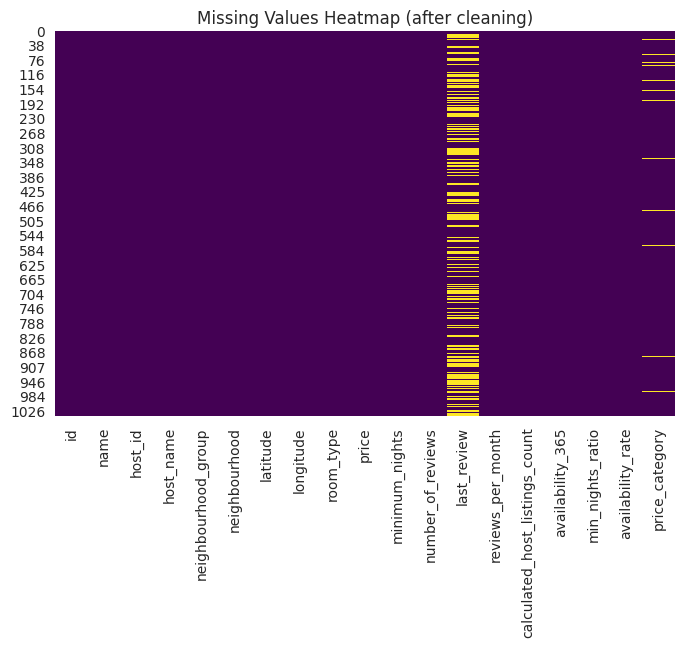

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (after cleaning)')
plt.show()

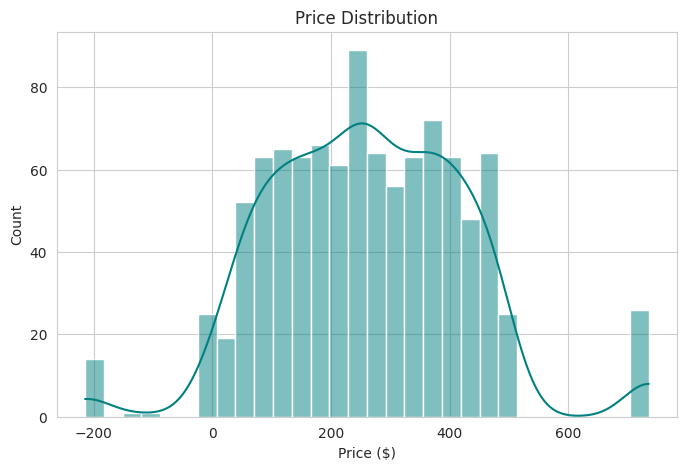

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='teal')
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.show()

/tmp/ipykernel_529/1490148642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index, palette='viridis')


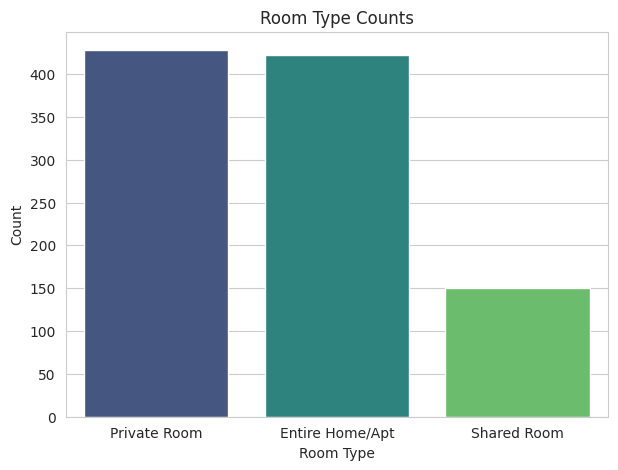

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index, palette='viridis')
plt.title('Room Type Counts')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_529/2186182057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index, palette='magma')


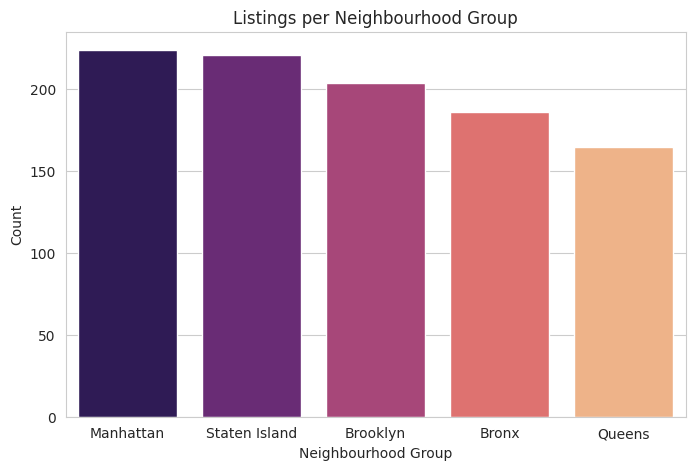

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index, palette='magma')
plt.title('Listings per Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_529/1555714392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='coolwarm')


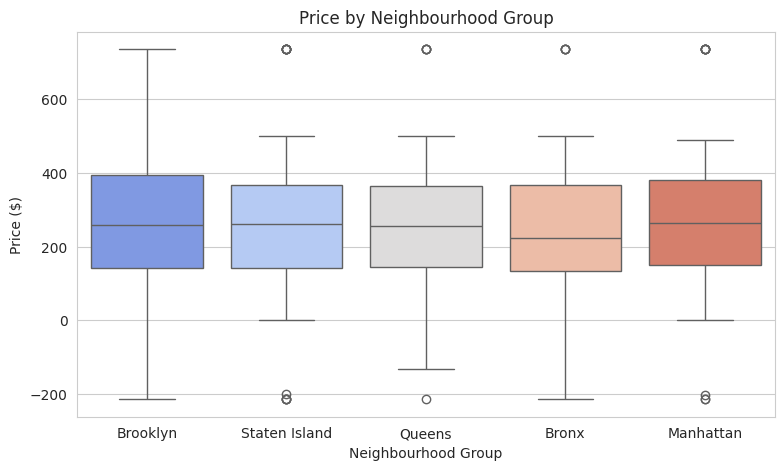

In [19]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='coolwarm')
plt.title('Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price ($)')
plt.show()

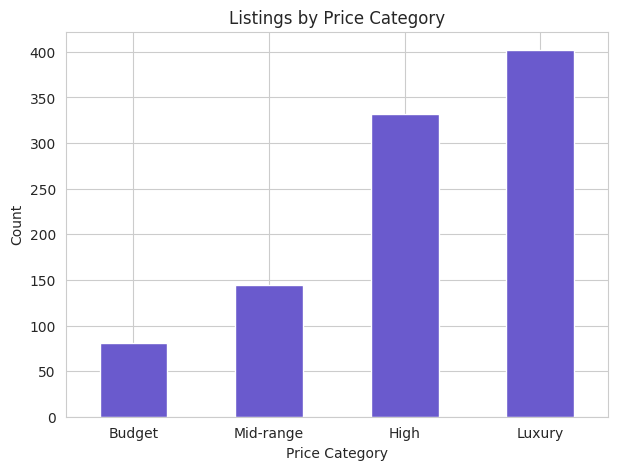

In [20]:
plt.figure(figsize=(7, 5))
df['price_category'].value_counts().reindex(['Budget', 'Mid-range', 'High', 'Luxury']).plot(kind='bar', color='slateblue')
plt.title('Listings by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

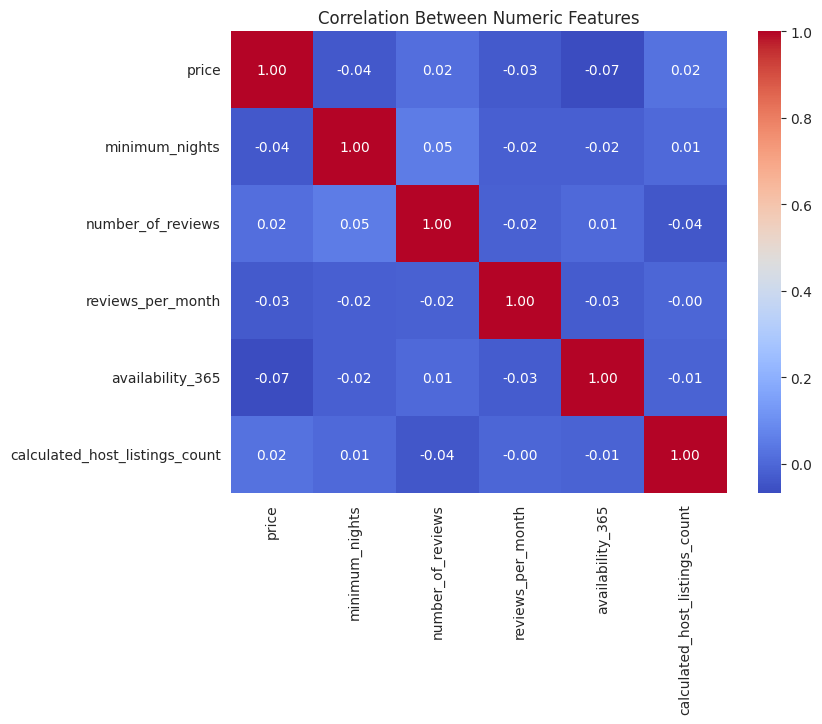

In [21]:
corr_cols = ['price', 'minimum_nights', 'number_of_reviews',
             'reviews_per_month', 'availability_365', 'calculated_host_listings_count']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

## Final verification

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 1039
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              1000 non-null   int64         
 1   name                            1000 non-null   str           
 2   host_id                         1000 non-null   str           
 3   host_name                       1000 non-null   str           
 4   neighbourhood_group             1000 non-null   str           
 5   neighbourhood                   1000 non-null   str           
 6   latitude                        1000 non-null   float64       
 7   longitude                       998 non-null    float64       
 8   room_type                       1000 non-null   str           
 9   price                           1000 non-null   float64       
 10  minimum_nights                  1000 non-null   float64       
 11  number_of_reviews   

In [23]:
df.isnull().sum()

id                                  0
name                                0
host_id                             0
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           2
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       414
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
min_nights_ratio                    0
availability_rate                   0
price_category                     41
dtype: int64

In [24]:
df.to_csv('airbnb_cleaned.csv', index=False)
print('Saved cleaned dataset as airbnb_cleaned.csv')
print('Final shape:', df.shape)

Saved cleaned dataset as airbnb_cleaned.csv
Final shape: (1000, 19)
